In [1]:
library(Seurat)
library(harmony)
library(spacexr)

library(ggplot2)
library(ggplotify)
library(ggsci)
library(scatterpie)
library(patchwork)
library(ggrastr)

library(ComplexHeatmap)
library(grid)
library(circlize)

library(Matrix)
library(dplyr)

Attaching SeuratObject

Seurat v4 was just loaded with SeuratObject v5; disabling v5 assays and
validation routines, and ensuring assays work in strict v3/v4
compatibility mode

Loading required package: Rcpp

scatterpie v0.2.6 Learn more at https://yulab-smu.top/



Loading required package: grid

ComplexHeatmap version 2.27.1
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))


ci

In [2]:
source('../R_function/ST_plot.R')
source('../R_function/knn_function.R')

In [3]:
Class_color <- c('#F0E685FF','#CE3D32FF','#5DB1DDFF','#466983FF',
                 '#5050FFFF','#837B8DFF','#BA6338FF','#802268FF','#6BD76BFF','#D595A7FF','#924822FF','#749B58FF')
names(Class_color) <- c('GLU','CGE','MGE','LGE',
                        'AST','EPC','MG','NB','OLG','OPC','VLMC','EC')

Archr_col <- c('#D51F26','#272E6A','#208A42','#89288F','#F47D2B','#FEE500','#8A9FD1',
               '#C06CAB','#E6C2DC','#90D5E4','#89C75F','#F37B7D','#9983BD','#D24B27',
               '#3BBCA8','#6E4B9E','#0C727C','#7E1416','#D8A767')
Subclass_color <- Archr_col[1:17]
names(Subclass_color) <- c('MGE.PVALB','MGE.PVALB-POSTN','MGE.SST','CGE.VIP','CGE.LAMP5','CGE.LAMP5-PRKG1','CGE.LAMP5-RELN','CGE.RELN','LGE.TSHZ1','LGE.FOXP1',
                           'Upper-IT','Middle-IT','Deep-IT','Deep-CT','Deep-PT','Deep-NP','Deep-RGS12')

Species_color <- c('#2A6EBBFF','#F0AB00FF','#C50084FF','#7D5CC6FF','#E37222FF','#69BE28FF','#00B2A9FF')
names(Species_color) <- c('marm','mous','bird','turt','axol','lung','lamp')

In [5]:
obj_bird_ST_raw_1 <- readRDS('/mnt/gandan/lishenglong/mut_sp/data/orig_data/zebrafinch_A1.rds')
obj_bird_ST_raw_2 <- readRDS('/mnt/gandan/lishenglong/mut_sp/data/orig_data/zebrafinch_D4.rds')
obj_bird_ST_raw_3 <- readRDS('/mnt/gandan/lishenglong/mut_sp/data/orig_data/zebrafinch_A5.rds')

In [6]:
obj_bird_ST_1 <- readRDS('/mnt/gandan/huangzhi/jupyter/Multispecies/Analysis/Region_defined/og_zb_a1_ce.rds')
obj_bird_ST_2 <- readRDS('/mnt/gandan/huangzhi/jupyter/Multispecies/Analysis/Region_defined/og_zb_d4_ce.rds')
obj_bird_ST_3 <- readRDS('/mnt/gandan/huangzhi/jupyter/Multispecies/Analysis/Region_defined/og_zb_a5_ce.rds')
rotation_coor <- function(raw_df,rotation){
    r_pi <- rotation*pi/180
    r_matrix <- matrix(c(cos(r_pi),-sin(r_pi),
                         sin(r_pi),cos(r_pi)),ncol=2,nrow=2)
    r_df <- as.matrix(raw_df)%*%r_matrix
    return(r_df)
    }
obj_bird_ST_1@meta.data[,c('x_raw','y_raw')] <- obj_bird_ST_1@meta.data[,c('x','y')]
obj_bird_ST_2@meta.data[,c('x_raw','y_raw')] <- obj_bird_ST_2@meta.data[,c('x','y')]
obj_bird_ST_3@meta.data[,c('x_raw','y_raw')] <- obj_bird_ST_3@meta.data[,c('x','y')]

obj_bird_ST_1@meta.data[,c('x','y')] <- rotation_coor(obj_bird_ST_1@meta.data[,c('x_raw','y_raw')],85)
obj_bird_ST_2@meta.data[,c('x','y')] <- rotation_coor(obj_bird_ST_2@meta.data[,c('x_raw','y_raw')],135)
obj_bird_ST_3@meta.data[,c('x','y')] <- rotation_coor(obj_bird_ST_3@meta.data[,c('x_raw','y_raw')],215)

In [7]:
obj_bird_ST_1[['RNA']] <- CreateAssayObject(obj_bird_ST_raw_1[['Spatial']]@counts[,colnames(obj_bird_ST_1)])
obj_bird_ST_2[['RNA']] <- CreateAssayObject(obj_bird_ST_raw_2[['Spatial']]@counts[,colnames(obj_bird_ST_2)])
obj_bird_ST_3[['RNA']] <- CreateAssayObject(obj_bird_ST_raw_3[['Spatial']]@counts[,colnames(obj_bird_ST_3)])
obj_bird_ST_1 <- NormalizeData(obj_bird_ST_1)
obj_bird_ST_2 <- NormalizeData(obj_bird_ST_2)
obj_bird_ST_3 <- NormalizeData(obj_bird_ST_3)

In [8]:
obj_bird_ST_1 <- FindVariableFeatures(obj_bird_ST_1,nfeatures = 5000,verbose=FALSE)
obj_bird_ST_2 <- FindVariableFeatures(obj_bird_ST_2,nfeatures = 5000,verbose=FALSE)
obj_bird_ST_3 <- FindVariableFeatures(obj_bird_ST_3,nfeatures = 5000,verbose=FALSE)
obj_bird_ST_1 <- ScaleData(obj_bird_ST_1,verbose=FALSE)
obj_bird_ST_2 <- ScaleData(obj_bird_ST_2,verbose=FALSE)
obj_bird_ST_3 <- ScaleData(obj_bird_ST_3,verbose=FALSE)
obj_bird_ST_1 <- RunPCA(obj_bird_ST_1,npcs=30,verbose=FALSE)
obj_bird_ST_2 <- RunPCA(obj_bird_ST_2,npcs=30,verbose=FALSE)
obj_bird_ST_3 <- RunPCA(obj_bird_ST_3,npcs=30,verbose=FALSE)

In [8]:
obj_bird_ST_1$sample <- 'S1' 
obj_bird_ST_2$sample <- 'S2' 
obj_bird_ST_3$sample <- 'S3'
obj_bird_ST <- merge(obj_bird_ST_1,list(obj_bird_ST_2,obj_bird_ST_3))

Warning message:
“Some cell names are duplicated across objects provided. Renaming to enforce unique cell names.”


In [19]:
source('../R_function/knn_function.R')

In [5]:
obj_bird_ST@active.assay <- 'RNA'
obj_bird_ST <- NormalizeData(obj_bird_ST)
#obj_bird_ST <- smooth_obj_data(obj_bird_ST,knn=25,round=5,slot='data',assays='RNA',smooth_function = 'spatial2')
#obj_bird_ST@assays$RNA@var.features <- intersect(intersect(obj_bird_ST_1@assays$RNA@var.features, obj_bird_ST_2@assays$RNA@var.features), obj_bird_ST_3@assays$RNA@var.features)
obj_bird_ST <- FindVariableFeatures(obj_bird_ST,nfeatures = 3000)
obj_bird_ST <- ScaleData(obj_bird_ST,verbose=FALSE)
obj_bird_ST <- RunPCA(obj_bird_ST,npcs=30,verbose=FALSE)
obj_bird_ST <- RunHarmony(obj_bird_ST,verbose = F,reduction.use = 'pca',group.by.vars = 'sample')

In [52]:
obj_bird_ST <- smooth_obj_data(obj_bird_ST,knn=25,round=2,slot='data',assays='RNA',smooth_function = 'magic',run_PCA = FALSE,reduction = 'harmony')

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 3.6 GiB”


In [53]:
obj_bird_ST <- FindVariableFeatures(obj_bird_ST,nfeatures = 3000)
obj_bird_ST <- ScaleData(obj_bird_ST,verbose=FALSE)
obj_bird_ST <- RunPCA(obj_bird_ST,npcs=30,verbose=FALSE,reduction.name = 'pca_magic')
obj_bird_ST <- RunHarmony(obj_bird_ST,verbose = F,reduction.use = 'pca_magic',group.by.vars = 'sample',reduction.save = 'harmony_magic')

Warning message:
“Key ‘PC_’ taken, using ‘pcamagic_’ instead”


In [54]:
obj_bird_ST <- RunUMAP(obj_bird_ST,dims=1:10,reduction = 'harmony_magic',verbose = F)

In [68]:
obj_bird_ST <- FindNeighbors(obj_bird_ST,reduction = 'harmony_magic',dims=1:10)
obj_bird_ST <- FindClusters(obj_bird_ST,resolution = 0.8)

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 25205
Number of edges: 741525

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8575
Number of communities: 16
Elapsed time: 4 seconds


pdf 
  2

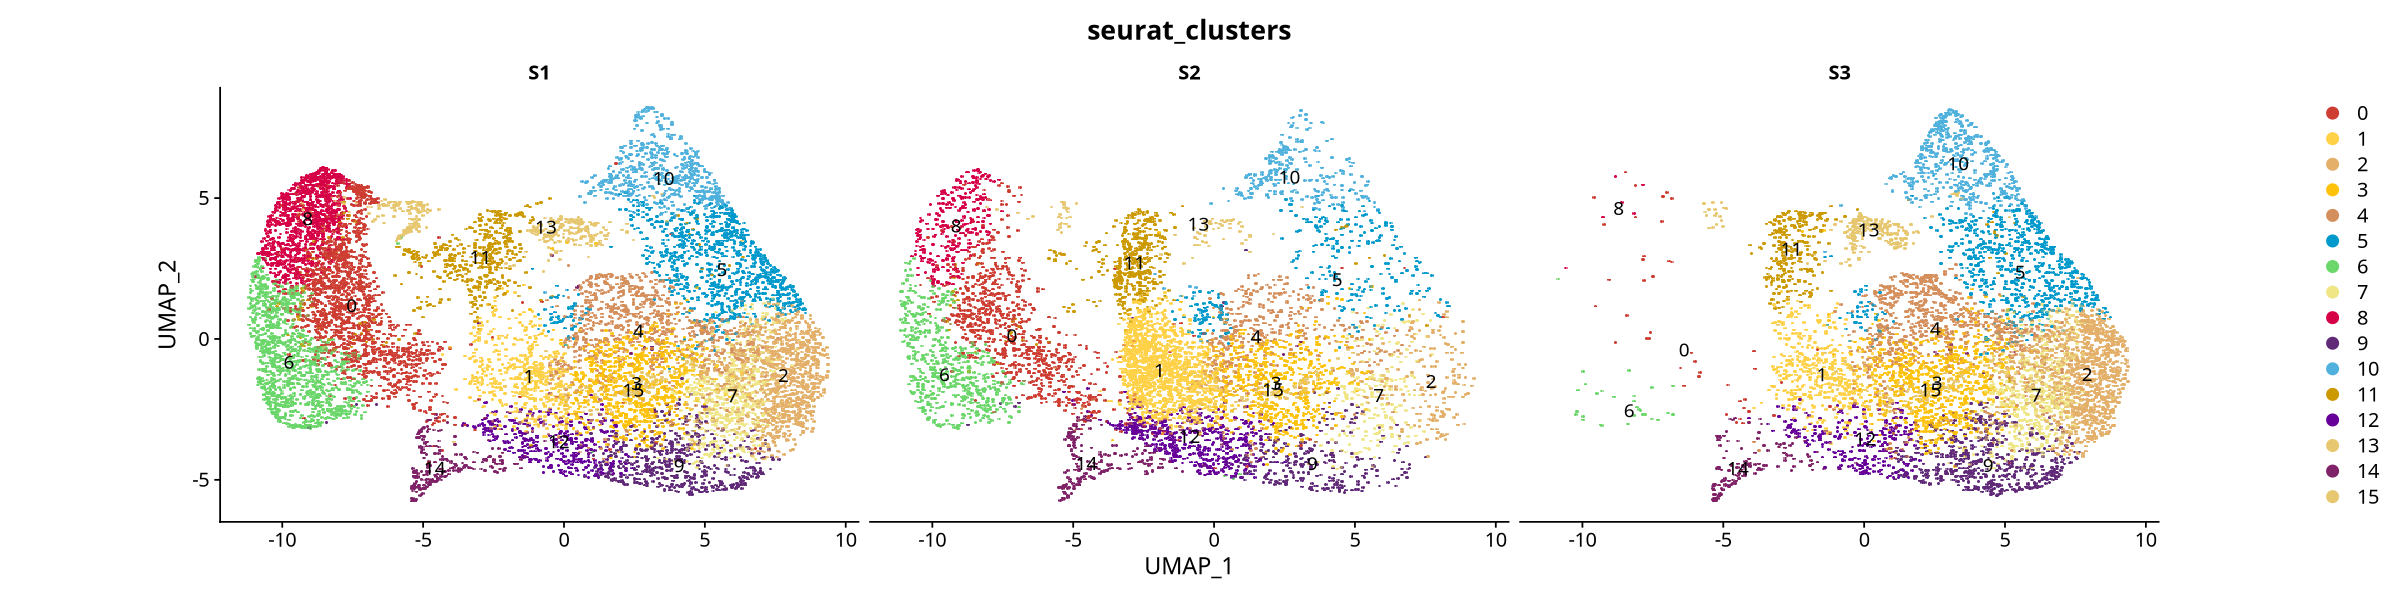

In [17]:
options(repr.plot.height=5,repr.plot.width=20)
p <- DimPlot(obj_bird_ST,reduction = 'umap',split.by = 'sample',pt.size = 2,raster=T,group.by='seurat_clusters',label=T)+
scale_color_manual(values = cluster_color,breaks = names(cluster_color))+
coord_fixed()
p
pdf('Plot/Region_cluster/Bird_umap_cluster.pdf',height = 5,width = 20)
p
dev.off()

In [14]:
cluster_color <- c('0'='#CE3D32','8'='#d60047',
  '1'='#ffd147','7'='#f0e685','3'='#ffc20a','13'='#E7C76F','2'='#e4af69','4'='#d58f5c','15'='#e7c76f',
  '6'='#6bd76b',
  '10'='#50b1dd','5'='#0099cc',
  '9'='#612a79','12'='#660099','14'='#802268',
  '11'='#CC9900','13'='#996600')
cluster_color <- cluster_color[ as.character(sort(as.numeric(names(cluster_color))))]

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


pdf 
  2

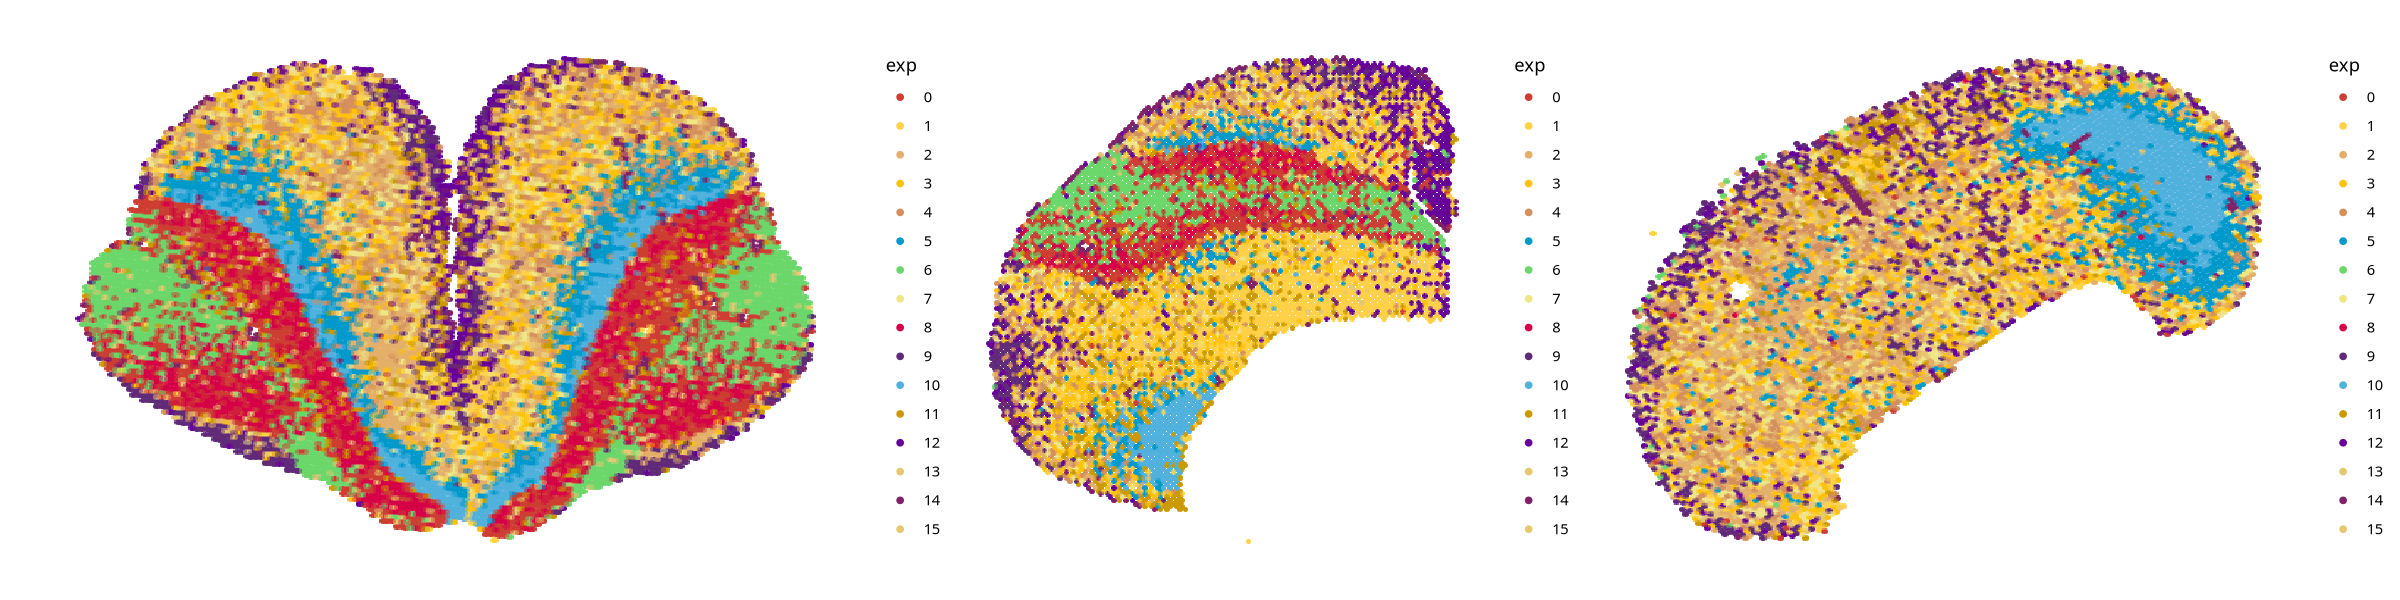

In [18]:
options(repr.plot.height=5,repr.plot.width=20)
p1 <- plot_spatial_col(obj = obj_bird_ST@meta.data[obj_bird_ST$sample=='S1',],col_name = 'seurat_clusters')+
scale_color_manual(values = cluster_color,breaks = names(cluster_color))
p2 <- plot_spatial_col(obj = obj_bird_ST@meta.data[obj_bird_ST$sample=='S2',],col_name = 'seurat_clusters')+
scale_color_manual(values = cluster_color,breaks = names(cluster_color))
p3 <- plot_spatial_col(obj = obj_bird_ST@meta.data[obj_bird_ST$sample=='S3',],col_name = 'seurat_clusters')+
scale_color_manual(values = cluster_color,breaks = names(cluster_color))
p1+p2+p3+plot_layout(ncol = 3)
pdf('Plot/Region_cluster/Bird_spatial_cluster.pdf',height = 5,width = 20)
p1+p2+p3+plot_layout(ncol = 3)
dev.off()

In [78]:
saveRDS(obj_bird_ST,'Analysis/Region_defined/Gene_bird.rds')

In [4]:
obj_bird_ST <- readRDS('Analysis/Region_defined/Gene_bird.rds')

In [21]:
impute_reduction <- obj_bird_ST@reductions$harmony_magic
rownames(impute_reduction@cell.embeddings) <- paste0(gsub('_.*','',rownames(impute_reduction@cell.embeddings)),c('S1'='_bird_a1','S2'='_bird_d4','S3'='_bird_a5')[obj_bird_ST$sample])
saveRDS( impute_reduction,'Analysis/Region_defined/Reduction_bird.rds')

In [19]:
save_real_plot(p1,dir_path = 'Plot/Region_mask/',name = 'bird_S1',plot_x_vector = obj_bird_ST@meta.data[obj_bird_ST$sample=='S1',]$x,plot_y_vector = obj_bird_ST@meta.data[obj_bird_ST$sample=='S1',]$y,edge_add = 50)
save_real_plot(p2,dir_path = 'Plot/Region_mask/',name = 'bird_S2',plot_x_vector = obj_bird_ST@meta.data[obj_bird_ST$sample=='S2',]$x,plot_y_vector = obj_bird_ST@meta.data[obj_bird_ST$sample=='S2',]$y,edge_add = 50)
save_real_plot(p3,dir_path = 'Plot/Region_mask/',name = 'bird_S3',plot_x_vector = obj_bird_ST@meta.data[obj_bird_ST$sample=='S3',]$x,plot_y_vector = obj_bird_ST@meta.data[obj_bird_ST$sample=='S3',]$y,edge_add = 50)

Coordinate system already present. Adding new coordinate system, which will
replace the existing one.
Coordinate system already present. Adding new coordinate system, which will
replace the existing one.
Coordinate system already present. Adding new coordinate system, which will
replace the existing one.


In [20]:
source('../R_function/ST_plot.R')

In [7]:
tif_df1 <- read_real_mask_plot('Plot/Region_mask/bird_S1_mask_-205.73_-41.08.tif',x_offset = -205.73, y_offset = -41.08)
tif_df2 <- read_real_mask_plot('Plot/Region_mask/bird_S2_mask_-287.59_-98.79.tif',x_offset = -287.59, y_offset = -98.79)
tif_df3 <- read_real_mask_plot('Plot/Region_mask/bird_S3_mask_-156.73_-191.17.tif',x_offset = -156.73, y_offset = -191.17)

In [8]:
tif_df1$region <- c('255'='H','210'='L','205'='E','200'='IH','150'='M','100'='N','125'='MI','50'='HA','75'='NL')[as.character(tif_df1$mask)]
tif_df2$region <- c('255'='H','210'='L','205'='E','200'='IH','150'='M','100'='N','125'='MI','50'='HA','75'='NL')[as.character(tif_df2$mask)]
tif_df3$region <- c('255'='H','210'='L','205'='E','200'='IH','150'='M','100'='N','125'='MI','50'='HA','75'='NL')[as.character(tif_df3$mask)]

In [9]:
meta1 <- df_add_mask(obj_bird_ST@meta.data[obj_bird_ST$sample=='S1',],tif_df1,imputation = T,mask_col = 'region')
meta2 <- df_add_mask(obj_bird_ST@meta.data[obj_bird_ST$sample=='S2',],tif_df2,imputation = T,mask_col = 'region')
meta3 <- df_add_mask(obj_bird_ST@meta.data[obj_bird_ST$sample=='S3',],tif_df3,imputation = T,mask_col = 'region')
obj_bird_ST@meta.data[obj_bird_ST$sample=='S1','region'] <- meta1$region
obj_bird_ST@meta.data[obj_bird_ST$sample=='S2','region'] <- meta2$region
obj_bird_ST@meta.data[obj_bird_ST$sample=='S3','region'] <- meta3$region

In [14]:
saveRDS(obj_bird_ST,'Analysis/Region_defined/Gene_bird.rds')

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


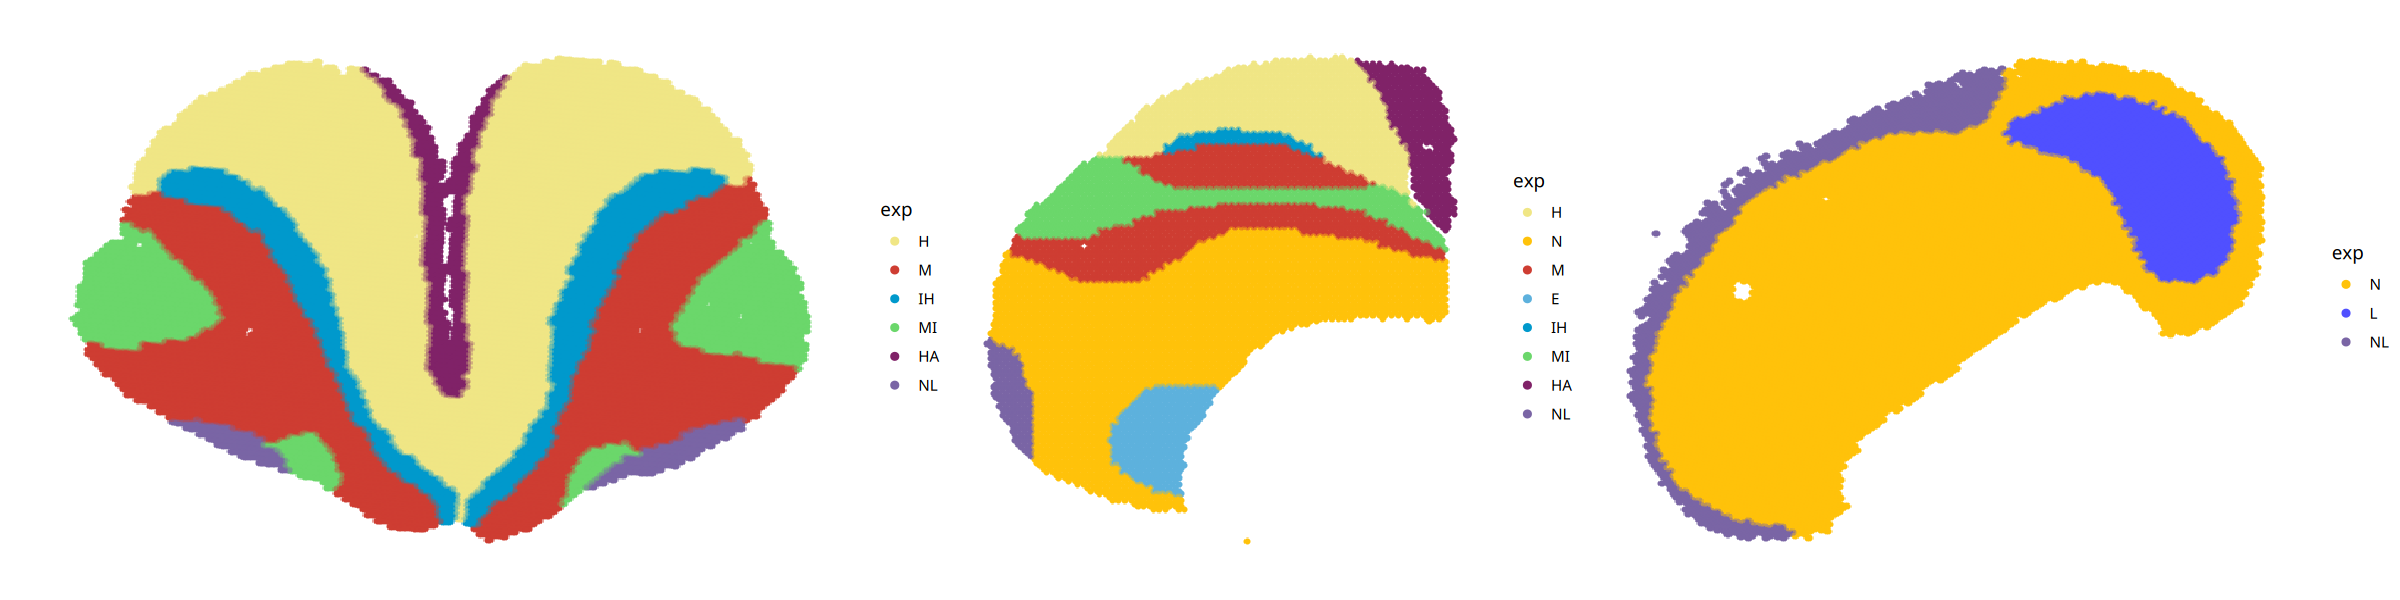

In [13]:
options(repr.plot.height=5,repr.plot.width=20)
p1 <- plot_spatial_col(obj = obj_bird_ST@meta.data[obj_bird_ST$sample=='S1',],col_name = 'region',size = 3.5)+
scale_color_manual(values = c('#f0e685','#ffc20a','#ce3d32','#5050ff','#5db1dd','#0099cc','#6bd76b','#802268','#7a65a5'),breaks = c('H','N','M','L','E','IH','MI','HA','NL'))
p2 <- plot_spatial_col(obj = obj_bird_ST@meta.data[obj_bird_ST$sample=='S2',],col_name = 'region',size = 3.5)+
scale_color_manual(values = c('#f0e685','#ffc20a','#ce3d32','#5050ff','#5db1dd','#0099cc','#6bd76b','#802268','#7a65a5'),breaks = c('H','N','M','L','E','IH','MI','HA','NL'))
p3 <- plot_spatial_col(obj = obj_bird_ST@meta.data[obj_bird_ST$sample=='S3',],col_name = 'region',size = 3.5)+
scale_color_manual(values = c('#f0e685','#ffc20a','#ce3d32','#5050ff','#5db1dd','#0099cc','#6bd76b','#802268','#7a65a5'),breaks = c('H','N','M','L','E','IH','MI','HA','NL'))
p1+p2+p3+plot_layout(ncol = 3)

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


pdf 
  2

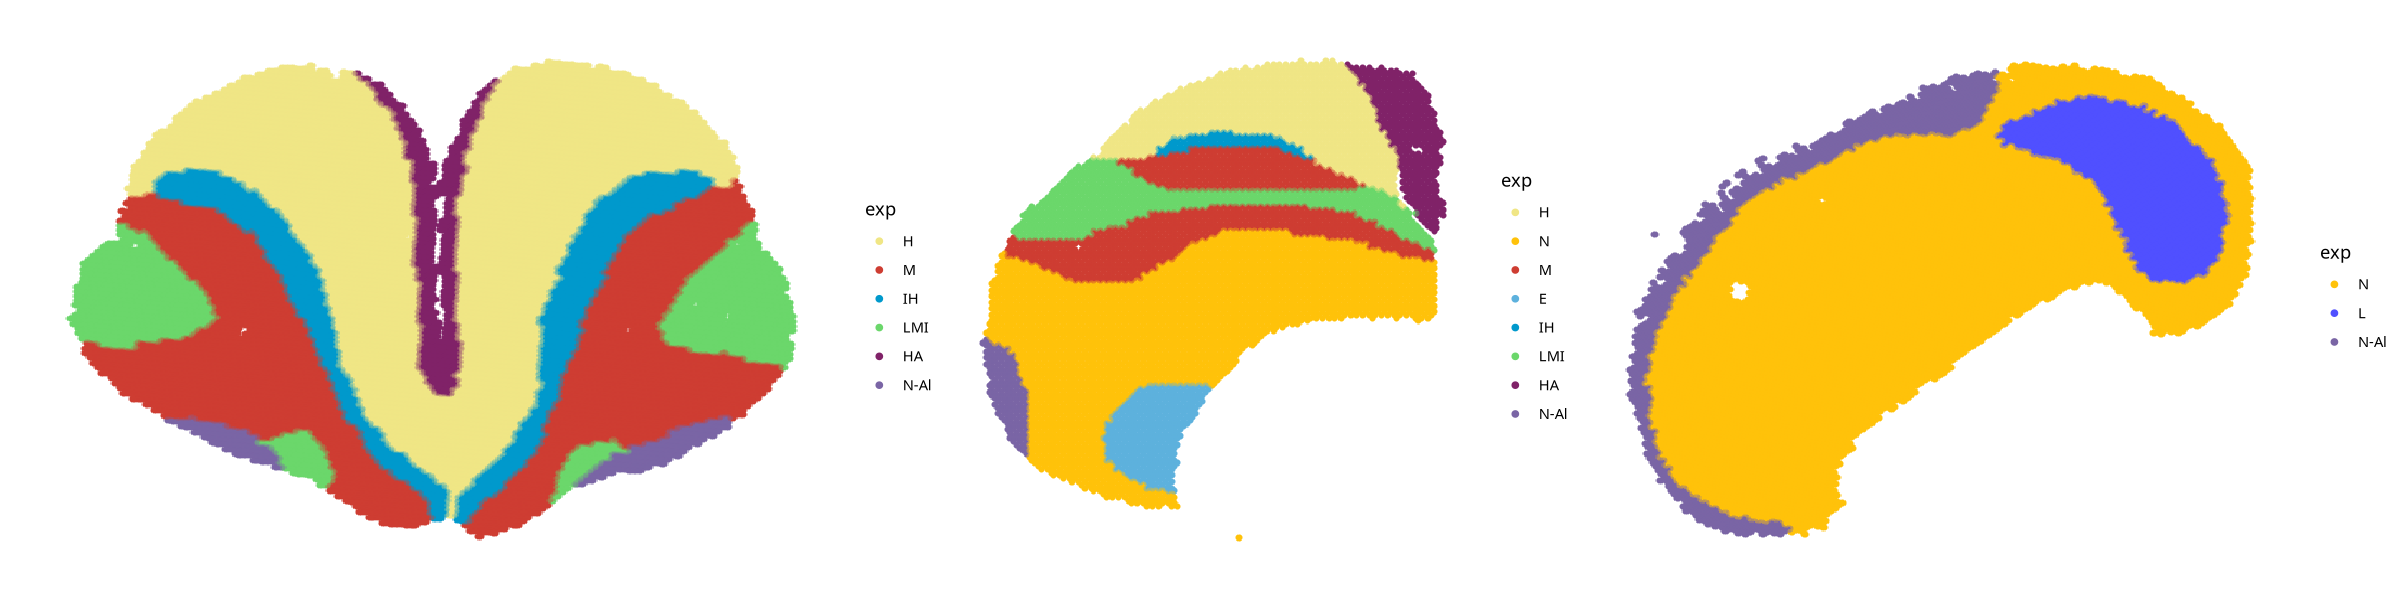

In [31]:
options(repr.plot.height=5,repr.plot.width=20)
p1 <- plot_spatial_col(obj = meta1,col_name = 'region',size = 3.5)+
scale_color_manual(values = c('#f0e685','#ffc20a','#ce3d32','#5050ff','#5db1dd','#0099cc','#6bd76b','#802268','#7a65a5'),breaks = c('H','N','M','L','E','IH','LMI','HA','N-Al'))
p2 <- plot_spatial_col(obj = meta2,col_name = 'region',size = 3.5)+
scale_color_manual(values = c('#f0e685','#ffc20a','#ce3d32','#5050ff','#5db1dd','#0099cc','#6bd76b','#802268','#7a65a5'),breaks = c('H','N','M','L','E','IH','LMI','HA','N-Al'))
p3 <- plot_spatial_col(obj = meta3,col_name = 'region',size = 3.5)+
scale_color_manual(values = c('#f0e685','#ffc20a','#ce3d32','#5050ff','#5db1dd','#0099cc','#6bd76b','#802268','#7a65a5'),breaks = c('H','N','M','L','E','IH','LMI','HA','N-Al'))
p1+p2+p3+plot_layout(ncol = 3)
pdf('Plot/Region_cluster/Bird_spatial_manual.pdf',height = 5,width = 20)
p1+p2+p3+plot_layout(ncol = 3)
dev.off()